In [1]:
import sys
sys.path.append("/project/src")

In [2]:
# Helper imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sksurv.util import Surv

# Pipeline imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

# Final model imports
from rsfmodel import RandomSurvivalForest

# Metric and evaluation imports
from sksurv.metrics import concordance_index_censored
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import KFold, RandomizedSearchCV


In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2024.csv"

In [4]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_29/2070981678.py:1: DtypeWarning: Columns (8,10,12,14,25,29,31,40,42,44,46,48,50,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,142,194,197,199,205,207,209,211,213,215,217,219,221,223,225,227,229,231,233,235,237,239,241,243,245,247,249,374,376,378,398,400,409,422,429,469,549,572,580,605,656,673,676,693,710,763,774,776,778,780,786,847,902,903,904,912,913,914,915,925,947,950,953) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [5]:
nacc_raw.rename(columns={"OUTCOME_EVENTMCI": "EVENT_MCI"}, inplace=True)

In [6]:
nacc_raw.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,...,NPATGAM3,NPATGAM4,NPATGAM5,NPATGFRN,NPATGFR1,NPATGFR2,NPATGFR3,NPATGFR4,EVENT_MCI,TIME
0,NACC003487,11,15,2023,2.0,1,0.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
1,NACC004687,11,14,2022,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2,NACC013204,8,7,2023,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
3,NACC014621,2,22,2024,2.0,2,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,NACC014791,12,12,2023,2.0,2,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


In [7]:
print(f"shape {nacc_raw.shape}")

shape (29673, 969)


# Helpers

## Contants

In [8]:
LOW_MISSINGNESS_THRESHOLD   = 20
HIGH_MISSINGNESS_THRESHOLD  = 80

In [9]:
SURVIVAL_EVENT_COL   = "EVENT_MCI"
SURVIVAL_TIME_COL    = "TIME"
MANDATORY_FEATURE    = "categorical__group_missing_indicator_0"

In [10]:
# this placeholder will be used to replace missing values that follows missing pattern
NOT_COLLECTED_PLACEHOLDER_VALUE     = -99.0
important_very_imbalanced_columns   = ["NACCFADM", "ELAT", "GAMES", "MOGAIT", "MOSLOW", "BRNINJ", "OTHPSY"]

According to EPV rule we need to provide as least 10 records per variable for the analysis and prediction to be reliable. After analysing the number of events during the eda - the number of features cannot extend 94 values (The 1 place is remained for the missing indicator, that should definetelly be in the final dataset)

In [11]:
N_IMPORTANT_FEATURES = 237

## Helper functions

In [12]:
def build_survival_target(df):
    """Return a structured survival array from *df*."""
    return Surv.from_dataframe(SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL, df)


def split_features_target(df):
    """Drop survival columns and return (X, y)."""
    X = df.drop(columns=[SURVIVAL_TIME_COL, SURVIVAL_EVENT_COL])
    y = build_survival_target(df)
    return X, y

def keep_available(features, columns):
    """Filter *features* to those present in *columns*."""
    col_set = set(columns)
    return [f for f in features if f in col_set]

In [13]:
def drop_useless_columns(df, columns_to_drop=[]):
    '''
      Drop columns that represent potential leakage variables
      or were considered as useless for the prediction
    '''
    print(f"Dropping useless columns and columns represented the MCI diagnosis")

    df_result = df.copy()
    df_result.drop(columns=columns_to_drop, inplace=True, errors='ignore')
    df_result.drop(columns=['NACCACTV', 'NACCADMD', 'NACCALZD', 'NACCALZP', 'PROBAD', 'PROBADIF', 'POSSAD', 'POSSADIF'], inplace=True, errors='ignore')
    df_result.drop(columns=['NACCMCII', 'NACCNORM', 'COGSTAT', 'VISITDAY', 'VISITYR', 'VISITMO', 'NACCETPR'], inplace=True, errors='ignore')
    df_result.drop(columns=['NACCID'], inplace=True, errors='ignore')
    return df_result

In [14]:
def filter_columns_by_missing_pattern(df, reference_col='HIV'):
    '''
        Define the missingness pattern by the reference column
        Filter via defined patterns all the columns that are not fully follows it
    '''
    print(f"Filtering columns by missing pattern")
    
    if reference_col not in df.columns:
        raise KeyError(f"Column '{reference_col}' not found in dataframe.")

    reference_mask = df[reference_col].isna().to_numpy()

    forward_columns     = []
    opposite_columns    = []

    for col in df.columns:
        col_mask = df[col].isna().to_numpy()

        if np.array_equal(col_mask, reference_mask):
            forward_columns.append(col)
        elif np.array_equal(col_mask, ~reference_mask):
            opposite_columns.append(col)

    kept_columns    = forward_columns + opposite_columns
    dropped_columns = [col for col in df.columns if col not in kept_columns]
    filtered_df     = df[kept_columns].copy()

    return filtered_df, forward_columns, opposite_columns, dropped_columns

In [15]:
def define_missingness(df):
  '''
    Group columns by missingness percentage into low, medium and high missingness groups
  '''
  print(f"Defining missingness")
  missing_percentage_per_column = df.isna().sum() / len(df) * 100

  low_missing     = missing_percentage_per_column[missing_percentage_per_column < LOW_MISSINGNESS_THRESHOLD].index.tolist()
  medium_missing  = missing_percentage_per_column[(missing_percentage_per_column >= LOW_MISSINGNESS_THRESHOLD) & (missing_percentage_per_column < HIGH_MISSINGNESS_THRESHOLD)].index.tolist()
  high_missing    = missing_percentage_per_column[missing_percentage_per_column >= HIGH_MISSINGNESS_THRESHOLD].index.tolist()

  return low_missing, medium_missing, high_missing

In [16]:
def define_categorical_and_continuous_columns(df):
    '''
      Group columns into categorical and continuous based on the number of unique values,
      with a special handling for some unusual categorical columns
    '''
    result_df           = df.copy()
    unusual_categorical = ['NACCBEHF']
    categorical_cols    = []
    continuous_cols     = []
    categorical_cols_by_unique_count = {}

    for col in result_df.columns:
        if col == 'EVENT_MCI':
            continue
        
        n_unique = result_df[col].nunique(dropna=True)
        if n_unique == 1:
            result_df.drop(columns=[col], inplace=True)
            continue
        if 2 <= n_unique <= 10 or col in unusual_categorical:
            categorical_cols.append(col)
            if n_unique not in categorical_cols_by_unique_count:
                categorical_cols_by_unique_count[n_unique] = []
            categorical_cols_by_unique_count[n_unique].append(col)
            continue
        continuous_cols.append(col)

    return categorical_cols, continuous_cols, categorical_cols_by_unique_count

In [17]:
def clean_columns(df):
    '''
      Delete columns with very high imbalance (for categorical) or very low variance (for continuous),
      with a special handling for some important but very imbalanced columns
    '''
    print(f"Cleaning columns")
    df_clean = df.copy()
    all_categorical_cols, all_continuous_cols, categorical_cols_by_unique_count = define_categorical_and_continuous_columns(df_clean)

    for col in all_categorical_cols:
        if col not in df_clean.columns:
            continue
        # check 1: overall imbalance
        col_value_proportions = df_clean[col].value_counts(normalize=True, dropna=True)
        if col_value_proportions.iloc[0] > 0.99:
            print(f"Column '{col}' is overall imbalanced ({col_value_proportions.iloc[0]:.2%})")
            df_clean.drop(columns=[col], inplace=True)
            continue  # no need to check further

        # check 2: separation within event groups (the actual cause of your problem)
        events = df_clean["EVENT_MCI"].astype(bool)
        for group_name, mask in [("events", events), ("non-events", ~events)]:
            group_proportions = df_clean.loc[mask, col].value_counts(normalize=True, dropna=True)
            if group_proportions.iloc[0] > 0.95:
                print(f"Column '{col}' is imbalanced within {group_name} ({group_proportions.iloc[0]:.2%})")
                df_clean.drop(columns=[col], inplace=True)
                break

    for col in all_continuous_cols:
        if col not in df_clean.columns:
            continue
        col_var = df_clean[col].var(numeric_only=True)
        if col_var == 0.0000:
            df_clean.drop(columns=[col], inplace=True)
            continue
        if col_var < 0.01 and col not in important_very_imbalanced_columns:
            print(f"Column '{col}' has very low variance ({col_var:.6f}); consider to drop it.")
            df_clean.drop(columns=[col], inplace=True)

    # keep column lists synchronized with the actually retained dataframe
    filtered_categorical_cols = keep_available(all_categorical_cols, df_clean.columns)
    filtered_continuous_cols = keep_available(all_continuous_cols, df_clean.columns)

    return df_clean, filtered_categorical_cols, filtered_continuous_cols


In [18]:
def decode_preprocessed_feature_name(feature_name, categorical_cols, continuous_cols):
    '''
      Decode the feature name from the preprocessed format
      (e.g., 'categorical__colname' or 'continuous__colname') to the original raw feature name,
    '''
    if feature_name.startswith('categorical__'):
        remainder = feature_name.replace('categorical__', '', 1)
        matching = [
            col for col in categorical_cols
            if remainder == col or remainder.startswith(f'{col}_')
        ]
        if len(matching) > 0:
            return max(matching, key=len)
        return remainder

    if feature_name.startswith('continuous__'):
        return feature_name.replace('continuous__', '', 1)

    return feature_name

def select_features_subset(df, feature_names, categorical_cols, continuous_cols):
    '''
      After feature selection select the subset of features
      by decoding each of them and finding in initial dataset the corresponding raw feature name
    '''
    raw_features = []
    for feature in feature_names:
        base_name = decode_preprocessed_feature_name(feature, categorical_cols, continuous_cols)

        if base_name in df.columns and base_name not in raw_features:
            raw_features.append(base_name)

    for required_col in ['TIME', 'EVENT_MCI', "group_missing_indicator"]:
        if required_col in df.columns and required_col not in raw_features:
            raw_features.append(required_col)

    return df[raw_features]

In [19]:
def low_missingness_complete_case_analysis(df, low_missingness_columns):
    '''
       Perform complete-case analysis on low-missing columns
    '''
    print(f"Complete-case analysis on low-missing columns")
    df_result = df.copy()
    low_missing_in_filtered = [c for c in low_missingness_columns if c in df_result.columns]
    if len(low_missing_in_filtered) > 0:
      nacc_missing_free_v2_v3 = df_result.dropna(
        subset=low_missing_in_filtered
      ).copy()
    else:
      nacc_missing_free_v2_v3 = df_result.copy()
    return nacc_missing_free_v2_v3

In [20]:
def create_missingness_indicators(df, column_ref_indicator='HIV'):
    print(f"Creating missingness indicator")
    df_result = df.copy()
    df_result['group_missing_indicator'] = np.where(
        df_result[column_ref_indicator].isna(), 1, 0
    )
    return df_result

## Pipeline custom components

In [21]:
class RareCategoryCollapser(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01, categorical_cols=None, non_collected_placeholder=None):
        self.threshold                  = threshold
        self.categorical_cols           = categorical_cols
        self.non_collected_placeholder  = non_collected_placeholder
        self.rare_categories_           = {}

    def fit(self, X, y=None):
        if self.non_collected_placeholder is None:
            raise ValueError('non_collected_placeholder cannot be None')

        df_result = X.copy()
        self.feature_names_in_ = np.asarray(df_result.columns, dtype=object)
        for col in self.categorical_cols:
            if col not in df_result.columns:
                continue

            value_counts                = df_result[col][df_result[col] != self.non_collected_placeholder].value_counts(normalize=True)
            rare_categories             = value_counts[value_counts < self.threshold].index.tolist()
            self.rare_categories_[col]  = rare_categories

        return self

    def transform(self, X):
        df_result = X.copy()

        for col, rare_categories in self.rare_categories_.items():
            if col in df_result.columns and len(rare_categories) > 0:
                rare_categories_str   = ', '.join(map(str, rare_categories))
                df_result[col]        = df_result[col].replace(rare_categories, f'{col}_{rare_categories_str}')
        return df_result

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        return np.asarray(input_features, dtype=object)


In [22]:
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols=None, selected_features_subset=None):
        self.categorical_cols           = categorical_cols
        self.selected_features_subset   = selected_features_subset
        self.encoder                    = None

    def fit(self, X, y=None):
        df_result       = X.copy()
        categorical_df  = df_result[self.categorical_cols].astype(str)
        self.encoder    = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.encoder.fit(categorical_df)

        feature_names = self.encoder.get_feature_names_out(self.categorical_cols)
        self.keep_columns_indices_ = [
            i for i, name in enumerate(feature_names)
            if not name.endswith(f'_{NOT_COLLECTED_PLACEHOLDER_VALUE}') and not name.endswith(f'_{NOT_COLLECTED_PLACEHOLDER_VALUE:.1f}')
        ]
        self.feature_names_out_ = feature_names[self.keep_columns_indices_]

        return self

    def transform(self, X):
        df_result       = X.copy()
        categorical_df  = df_result[self.categorical_cols].astype(str)
        encoded_array   = self.encoder.transform(categorical_df)
        encoded_array   = encoded_array[:, self.keep_columns_indices_]
        return encoded_array

    def get_feature_names_out(self):
        return np.asarray(self.feature_names_out_, dtype=object)


In [23]:
class CustomConstantImputer(BaseEstimator, TransformerMixin):
    def __init__(self, fill_value=None):
        self.fill_value = fill_value

    def fit(self, X, y=None):
        if self.fill_value is None:
            raise ValueError('fill_value cannot be None')
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        df_result = X.copy()
        df_result.fillna(self.fill_value, inplace=True)
        return df_result

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        return np.asarray(input_features, dtype=object)


## Feature selection

In [36]:
def rsf_vimp_feature_selection(x_data, y_data, n_features, parameters=None):
    if parameters is None:
        raise ValueError('parameters cannot be None')

    rsf = RandomSurvivalForest(
        num_trees     = parameters['num_trees'],
        min_node_size = parameters['min_node_size'],
        mtry          = parameters['mtry'],
        importance    = "permutation"
    )
    rsf.fit(x_data, y_data)
    vimp_importance = rsf.get_importance()
    return vimp_importance.head(n_features).index.tolist()


# Preprocessing pipeline

In [25]:
def build_preprocessing_pipeline(categorical_columns, continuous_columns, selected_features_subset=None):
  # Categorical pipeline
  categorical_pipeline = Pipeline([
    ('imputer', CustomConstantImputer(fill_value=NOT_COLLECTED_PLACEHOLDER_VALUE)),
    ('rare_collapser', RareCategoryCollapser(
      threshold=0.01,
      categorical_cols=categorical_columns,
      non_collected_placeholder=NOT_COLLECTED_PLACEHOLDER_VALUE,
    )),
    ('encoder', CustomOneHotEncoder(categorical_cols=categorical_columns, selected_features_subset=selected_features_subset)),
  ]).set_output(transform='pandas')

  # Continuous features pipeline
  continious_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('boxcox-transformer', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
  ]).set_output(transform='pandas')

  columns_preprocessing_pipeline = ColumnTransformer([
    ('categorical', categorical_pipeline, categorical_columns),
    ('continuous', continious_pipeline, continuous_columns),
  ]).set_output(transform='pandas')

  return Pipeline([
    ('columns_preprocessing', columns_preprocessing_pipeline),
  ]).set_output(transform='pandas')


# Dataset preprocessor class

In [26]:
class BaseDatasetPreprocessor:
    def __init__(self):
        self._cleaned_df          = None
        self._low_missing_cols    = None
        self._categorical_cols    = None
        self._continuous_cols     = None
        self._pipeline            = None
        self._pipeline_input_cols = None

    def fit_transform(self, df):
        """
          Fit the base pipeline on df and return preprocessed (X, y).

          Steps
          -----
          1. Structural cleanup (drop useless / low-variance columns, missingness
          indicators, column typing).
          2. Complete-case analysis on low-missingness columns.
          3. Fit + apply the preprocessing pipeline on the full cleaned data.
        """
        self._fit_structural_cleanup(df)
        X, y = self._apply_complete_case_and_split(self._cleaned_df)
        X_preprocessed = self._fit_transform_pipeline(X)
        return X_preprocessed, y

    def transform(self, df):
        """
          Apply the already-fitted base pipeline to df and return (X, y).
        """
        self._assert_pipeline_fitted()
        self._fit_structural_cleanup(df)
        X, y = self._apply_complete_case_and_split(self._cleaned_df)
        X_preprocessed = self._transform_pipeline(X)
        return X_preprocessed, y

    def _fit_structural_cleanup(self, df):
        """
          Stateless cleaning: drop useless columns, apply missingness filtering,
          create missingness indicators, and infer column types.
        """
        df = drop_useless_columns(df.copy())

        low_missing, _medium_missing, _high_missing = define_missingness(df)
        medium_filtered, *_ = filter_columns_by_missing_pattern(df[_medium_missing])

        retained_cols = medium_filtered.columns.tolist() + low_missing
        df            = df[retained_cols].copy()

        df = create_missingness_indicators(df)
        df, categorical_cols, continuous_cols = clean_columns(df)

        self._categorical_cols = [c for c in categorical_cols if c not in (SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL)]
        self._continuous_cols  = [c for c in continuous_cols  if c not in (SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL)]
        self._cleaned_df       = df
        self._low_missing_cols = low_missing

    def _apply_complete_case_and_split(self, df, restrict_to_cols=None):
        """
          Run complete-case analysis on low missingness columns
        """
        low_missingness_cols  = keep_available(restrict_to_cols or self._low_missing_cols, df.columns)
        cleaned               = low_missingness_complete_case_analysis(df, low_missingness_cols)
        return split_features_target(cleaned)

    def _fit_transform_pipeline(self, X):
        active_cat  = keep_available(self._categorical_cols, X.columns)
        active_cont = keep_available(self._continuous_cols,  X.columns)

        self._pipeline            = build_preprocessing_pipeline(active_cat, active_cont)
        self._pipeline_input_cols = list(X.columns)
        return self._pipeline.fit_transform(X)

    def _transform_pipeline(self, X):
        X_aligned = X.reindex(columns=self._pipeline_input_cols, fill_value=np.nan)
        return self._pipeline.transform(X_aligned)

    def _assert_pipeline_fitted(self):
        if self._pipeline is None:
            raise RuntimeError(
                "Pipeline is not fitted. Call fit_transform() first."
            )

In [37]:
class FullDatasetPreprocessor(BaseDatasetPreprocessor):
    def __init__(self, n_important_features=N_IMPORTANT_FEATURES, best_rsf_vimp_parameters=None):
        super().__init__()
        self.n_important_features     = n_important_features
        self._selected_features       = None
        self._train_categorical_cols  = None
        self._train_continuous_cols   = None
        self.best_parameters          = best_rsf_vimp_parameters
  
    def fit_transform(self, df):
        """
          Fit the full pipeline on df and return (X, y).
          Extends the base fit with feature selection and subset re-fitting.

          Steps
          -----
          1–3. Base preprocessing (see :class:`BaseDatasetPreprocessor`).
          4.   RSF-VIMP feature selection → select top-N features.
          5.   Complete-case analysis restricted to the selected feature subset.
          6.   Re-fit + apply the pipeline on the reduced subset.
        """
        X_preprocessed, y_full = super().fit_transform(df)

        # Snapshot column roles before they are overwritten by subset re-fit
        self._train_categorical_cols  = list(self._categorical_cols)
        self._train_continuous_cols   = list(self._continuous_cols)
        self._selected_features       = self._select_features(X_preprocessed, y_full)

        X_final, y_final = self._build_subset_pipeline(
            selected_features=self._selected_features,
            categorical_cols=self._train_categorical_cols,
            continuous_cols=self._train_continuous_cols,
            pipeline_mode="fit_transform",
        )
        return X_final, y_final

    def transform(self, df):
        """
          Apply the already-fitted full pipeline to df and return (X, y).
        """
        self._assert_fully_fitted()

        self._fit_structural_cleanup(df)

        X_final, y_final = self._build_subset_pipeline(
            selected_features=self._selected_features,
            categorical_cols=self._train_categorical_cols,
            continuous_cols=self._train_continuous_cols,
            pipeline_mode="transform",
        )
        return X_final, y_final

    def _select_features(self, X, y):
        """
          Select subset of features to reduce the dimensionality of the dataset
          Applicable only on training data.
        """
        selected = rsf_vimp_feature_selection(
            X, y, n_features=self.n_important_features, parameters=self.best_parameters
        )
        if MANDATORY_FEATURE not in selected:
            selected.append(MANDATORY_FEATURE)
        return selected

    def _build_subset_pipeline(self, selected_features, categorical_cols, continuous_cols, pipeline_mode):
        """
          Reverse-map selected preprocessed feature names to raw columns, apply
          complete-case analysis on the subset, and re-run the pipeline.
        """
        raw_subset = select_features_subset(
            self._cleaned_df,
            selected_features,
            categorical_cols,
            continuous_cols,
        )

        subset_low_missing = keep_available(self._low_missing_cols, raw_subset.columns)
        subset_cleaned     = low_missingness_complete_case_analysis(raw_subset, subset_low_missing)
        X_subset, y_subset = split_features_target(subset_cleaned)

        if pipeline_mode == "fit_transform":
            X_preprocessed = self._fit_transform_pipeline(X_subset)
        else:
            X_preprocessed = self._transform_pipeline(X_subset)

        final_features = keep_available(selected_features, X_preprocessed.columns)
        return X_preprocessed[final_features], y_subset

    def _assert_fully_fitted(self):
        if self._pipeline is None or self._selected_features is None:
            raise RuntimeError(
                "Preprocessor is not fully fitted. Call fit_transform() on training data first."
            )


# Train test split

In [28]:
train_df, test_df = train_test_split(
    nacc_raw,
    test_size=0.2,
    random_state=42,
    stratify=nacc_raw['EVENT_MCI'],
)

# Feature selection RSF VIMP tunning

We need to tune feature selection parameters in order to reliably select the subset of features for the further dataset processing. This code is commented and used only when when the entire split train/test is rerun

In [29]:
base_data_preprocessor = BaseDatasetPreprocessor()
X_train_for_tunning, y_train_for_tunning = base_data_preprocessor.fit_transform(train_df)
X_train_for_tunning.head()

Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns
Column 'DECCLMOT' is imbalanced within non-events (95.14%)
Column 'LBDEVAL' is imbalanced within non-events (98.44%)
Column 'FTLDEVAL' is imbalanced within events (96.21%)
Column 'AMNDEM' is imbalanced within events (95.03%)
Column 'PCA' is imbalanced within events (95.10%)
Column 'AMYLCSF' is imbalanced within non-events (97.04%)
Column 'FDGAD' is imbalanced within non-events (98.40%)
Column 'TAUPETAD' is imbalanced within events (95.39%)
Column 'CSFTAU' is imbalanced within non-events (97.11%)
Column 'FDGFTLD' is imbalanced within non-events (98.48%)
Column 'TPETFTLD' is imbalanced within events (96.01%)
Column 'DATSCAN' is imbalanced within events (97.45%)
Column 'OTHBIOM' is imbalanced within non-events (96.90%)
Column 'OTHMUT' is imbalanced within events (96.47%)
Column 'MSA' is overall imbalanced (99.98%)
Colu

,categorical__DECCLCOG_0.0,categorical__DECCLCOG_1.0,categorical__DECCLBE_0.0,categorical__DECCLBE_1.0,categorical__DXMETHOD_1.0,categorical__DXMETHOD_2.0,categorical__DXMETHOD_3.0,categorical__AMYLPET_0.0,categorical__AMYLPET_1.0,categorical__AMYLPET_8.0,...,continuous__HRATE,continuous__CDRSUM,continuous__NACCGDS,continuous__ANIMALS,continuous__VEG,continuous__TRAILA,continuous__TRAILB,continuous__NACCAGEB,continuous__NACCAMD,continuous__NACCBMI
20594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.186976,-0.595241,-1.055427,-0.978429,0.170596,-0.885255,0.102726,0.808320,-0.971484,-0.901941
9907,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.730619,1.480032,1.816845,-0.588750,-1.017767,0.512656,0.560735,0.459850,1.182413,-1.011127
15544,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.262281,-0.595241,0.852736,1.136554,0.834215,-1.719717,-0.969898,0.347158,0.633071,-0.402719
22400,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,-0.161456,-0.595241,1.171740,0.815282,0.834215,-0.748721,-1.584548,-0.190464,0.633071,-0.520743
22160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.262281,-0.595241,-1.055427,-0.978429,1.260805,0.200705,0.102726,0.690427,-0.041928,0.050480


In [30]:
case_weights = compute_sample_weight(
  class_weight='balanced',
  y=y_train_for_tunning["EVENT_MCI"]
)

In [31]:
features_num = X_train_for_tunning.shape[1]

def concordance_index_scorer(estimator, X, y):
    risk_scores = estimator.predict(X)
    c_index = concordance_index_censored(y['EVENT_MCI'], y['TIME'], risk_scores)
    return c_index[0] 

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_distributions = {
    'num_trees': [500, 1000],
    'mtry': ['sqrt', 'log2'],
    'min_node_size': np.arange(5, 50),
}
rsf = RandomSurvivalForest()
random_search = RandomizedSearchCV(
    estimator=rsf,
    param_distributions=param_distributions,
    n_iter=8,
    cv=cv,
    scoring=concordance_index_scorer,
)


In [32]:
random_search.fit(X_train_for_tunning, y_train_for_tunning)
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  


Growing trees.. Progress: 5%. Estimated remaining time: 10 minutes, 14 seconds.
Growing trees.. Progress: 9%. Estimated remaining time: 11 minutes, 7 seconds.
Growing trees.. Progress: 13%. Estimated remaining time: 10 minutes, 44 seconds.
Growing trees.. Progress: 17%. Estimated remaining time: 10 minutes, 17 seconds.
Growing trees.. Progress: 22%. Estimated remaining time: 9 minutes, 55 seconds.
Growing trees.. Progress: 26%. Estimated remaining time: 9 minutes, 12 seconds.
Growing trees.. Progress: 31%. Estimated remaining time: 8 minutes, 41 seconds.
Growing trees.. Progress: 35%. Estimated remaining time: 8 minutes, 0 seconds.
Growing trees.. Progress: 40%. Estimated remaining time: 7 minutes, 26 seconds.
Growing trees.. Progress: 44%. Estimated remaining time: 6 minutes, 48 seconds.
Growing trees.. Progress: 48%. Estimated remaining time: 6 minutes, 21 seconds.
Growing trees.. Progress: 53%. Estimated remaining time: 5 minutes, 46 seconds.
Growing trees.. Progress: 57%. Estimated

# Final dataset preprocessing

In [38]:
data_preprocessor = FullDatasetPreprocessor(best_rsf_vimp_parameters=random_search.best_params_)
X_train, y_train = data_preprocessor.fit_transform(df=train_df)
X_test, y_test = data_preprocessor.transform(df=test_df)

Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns
Column 'DECCLMOT' is imbalanced within non-events (95.14%)
Column 'LBDEVAL' is imbalanced within non-events (98.44%)
Column 'FTLDEVAL' is imbalanced within events (96.21%)
Column 'AMNDEM' is imbalanced within events (95.03%)
Column 'PCA' is imbalanced within events (95.10%)
Column 'AMYLCSF' is imbalanced within non-events (97.04%)
Column 'FDGAD' is imbalanced within non-events (98.40%)
Column 'TAUPETAD' is imbalanced within events (95.39%)
Column 'CSFTAU' is imbalanced within non-events (97.11%)
Column 'FDGFTLD' is imbalanced within non-events (98.48%)
Column 'TPETFTLD' is imbalanced within events (96.01%)
Column 'DATSCAN' is imbalanced within events (97.45%)
Column 'OTHBIOM' is imbalanced within non-events (96.90%)
Column 'OTHMUT' is imbalanced within events (96.47%)
Column 'MSA' is overall imbalanced (99.98%)
Colu

In [39]:
X_train_reset = X_train.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

In [40]:
X_train_reset.shape, X_test_reset.shape

((10019, 237), (2427, 237))

In [41]:
train_df = pd.concat([X_train_reset, pd.DataFrame(y_train)], axis=1)
test_df = pd.concat([X_test_reset, pd.DataFrame(y_test)], axis=1)

train_df.to_csv("train_preprocessed.csv", index=False)
test_df.to_csv("test_preprocessed.csv", index=False)

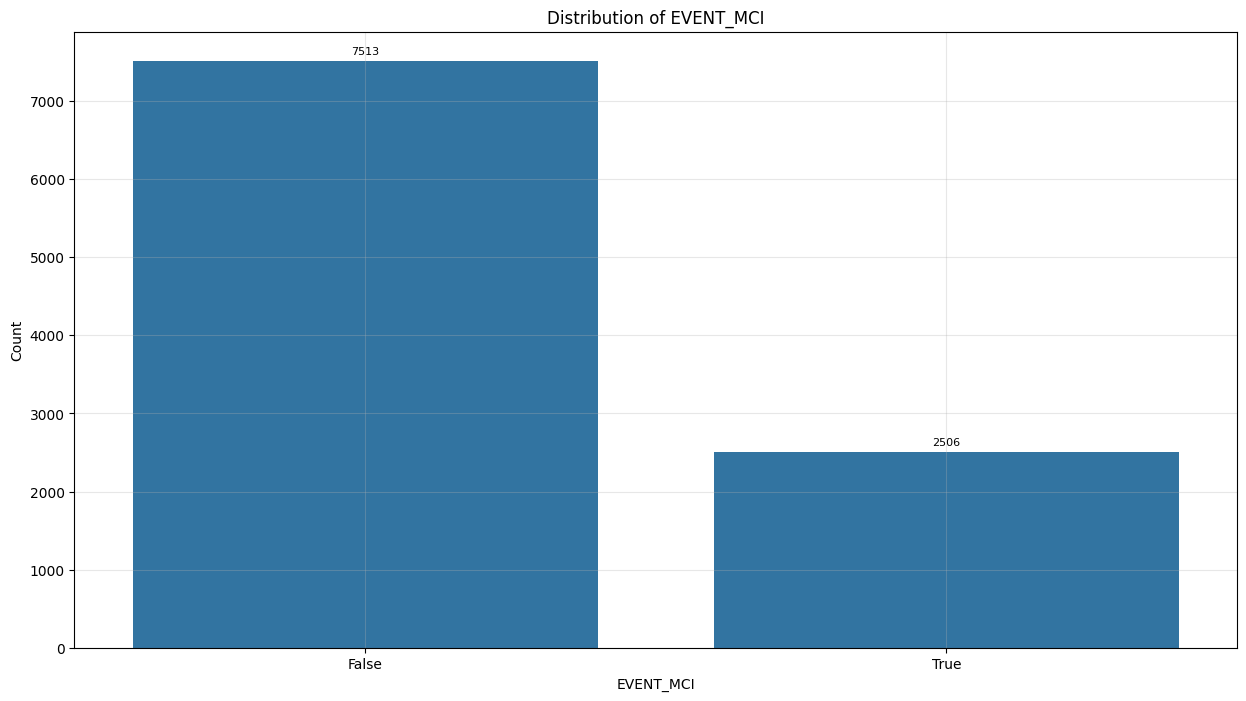

In [42]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=train_df['EVENT_MCI'].value_counts().index, y=train_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
train_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
False    0.749875
True     0.250125
Name: proportion, dtype: float64